In [1]:
# ============================================================
# GOOGLE PLAY STORE ANALYTICS - CASE STUDY
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/abhik12295/playstore-Dataset/main/googleplaystore.csv"
df = pd.read_csv(url)
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
# -------------------------------
# Basic Cleaning
# -------------------------------
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = (
    df["Installs"]
      .astype(str)
      .str.replace(",", "")
      .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Size"] = (
    df["Size"]
      .astype(str)
      .str.replace("M", "", regex=False)
      .str.replace("k", "", regex=False)
      .str.replace("Varies with device", "")
)

df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

df = df.dropna()

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


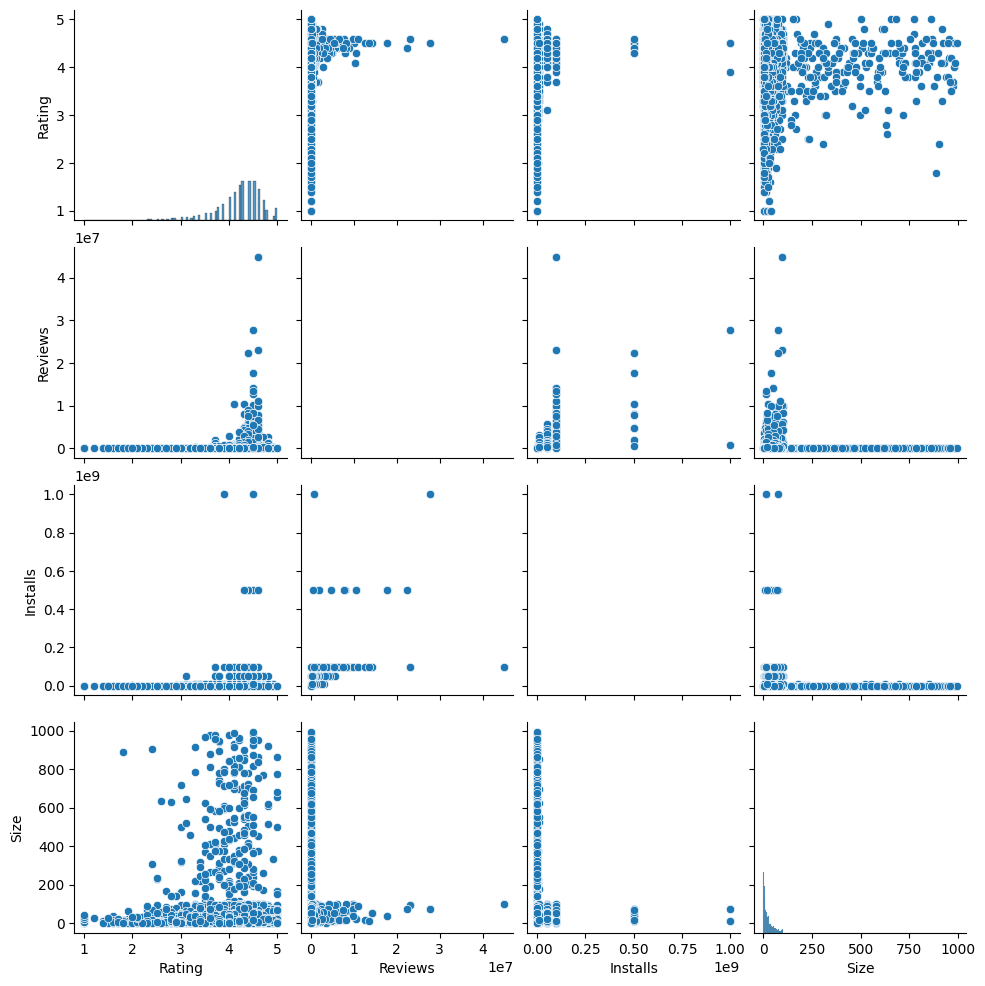

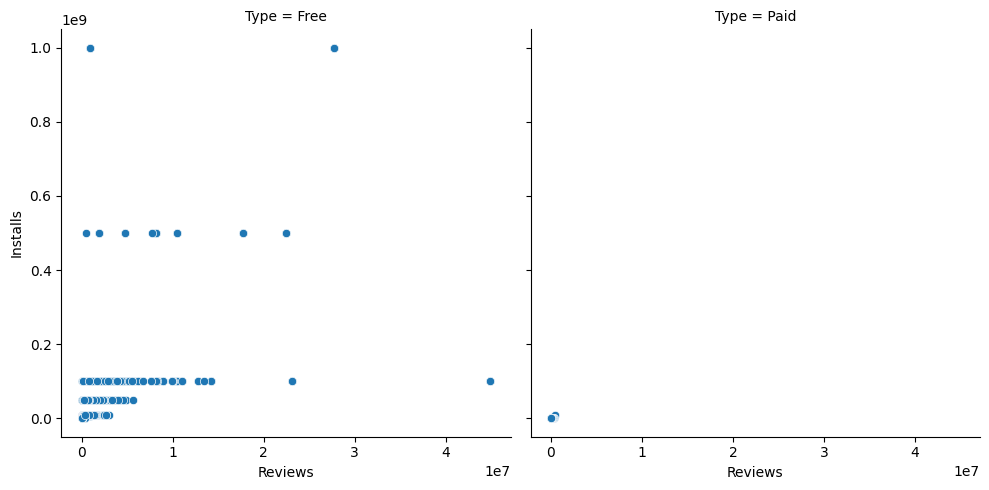

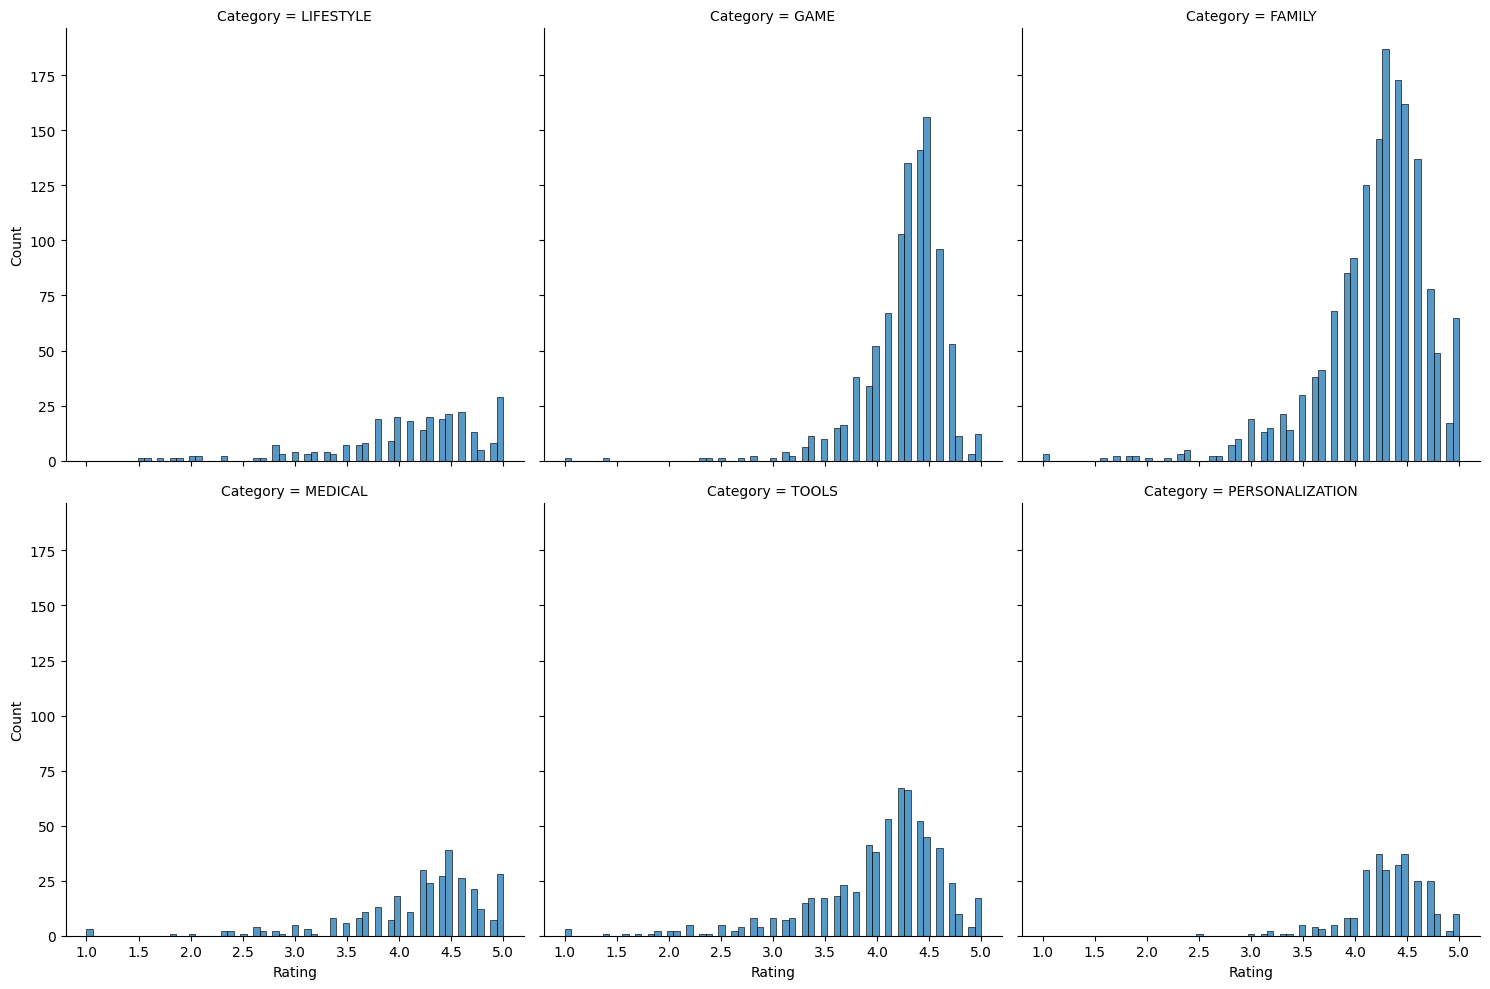

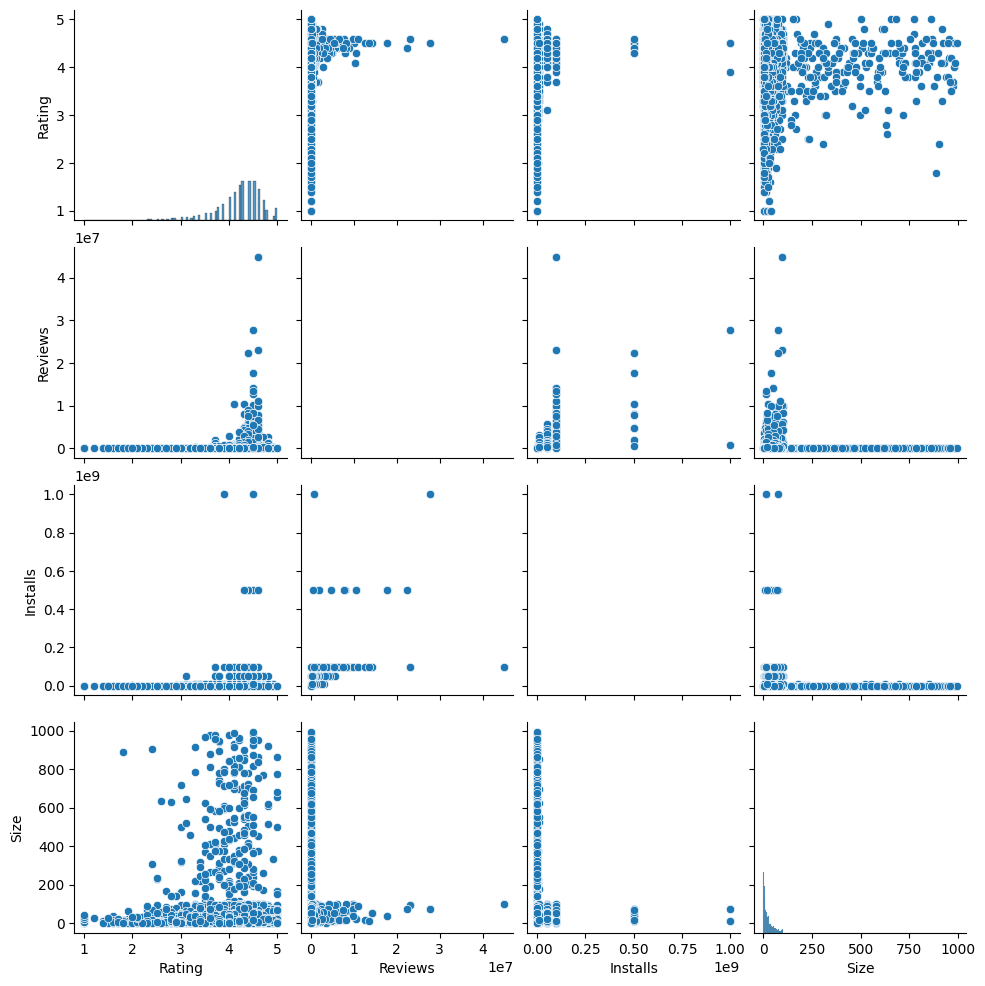

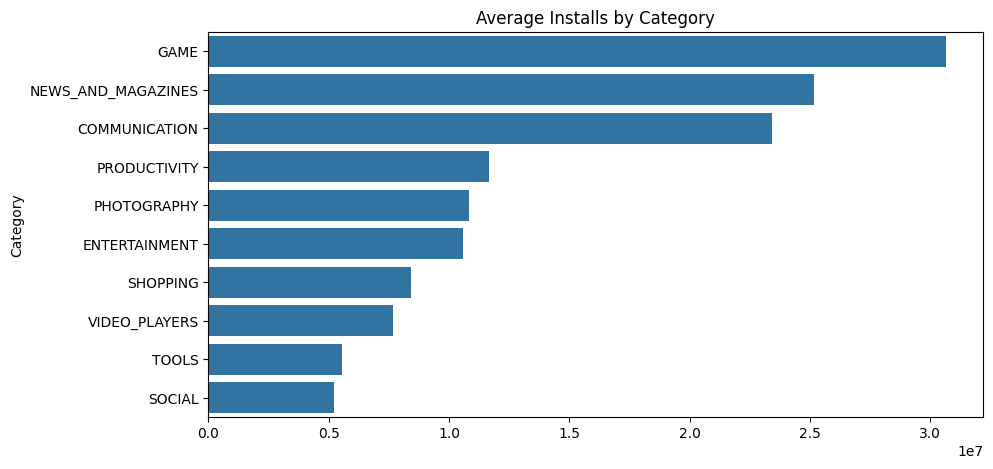

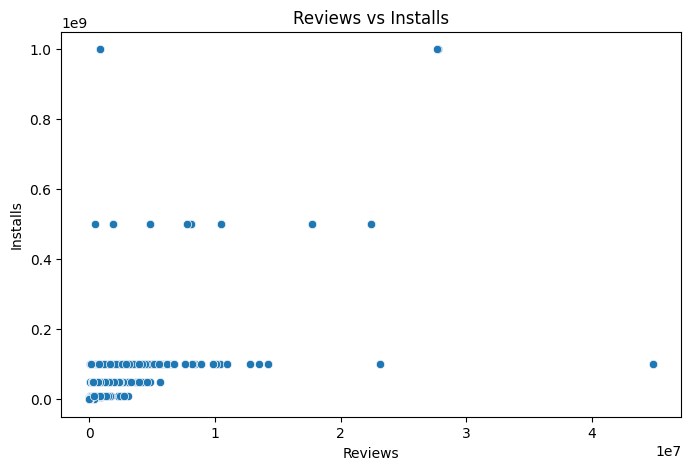

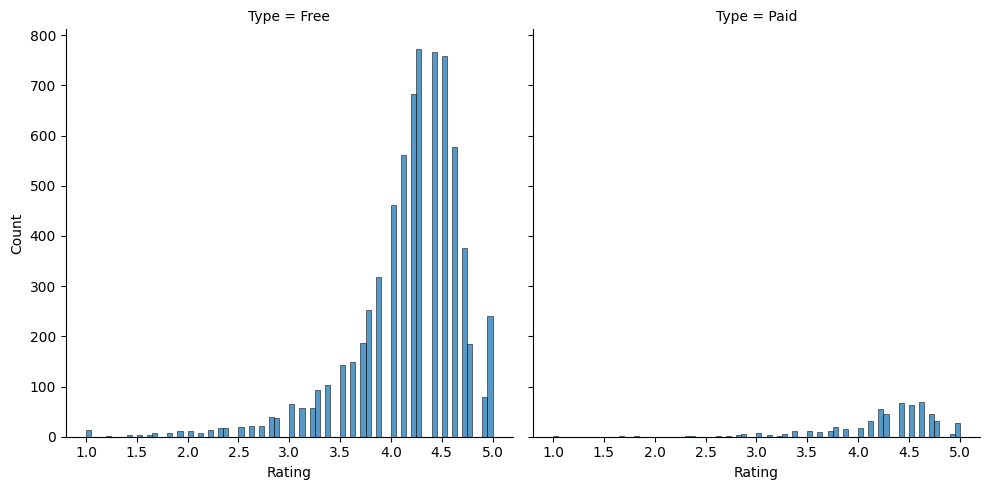

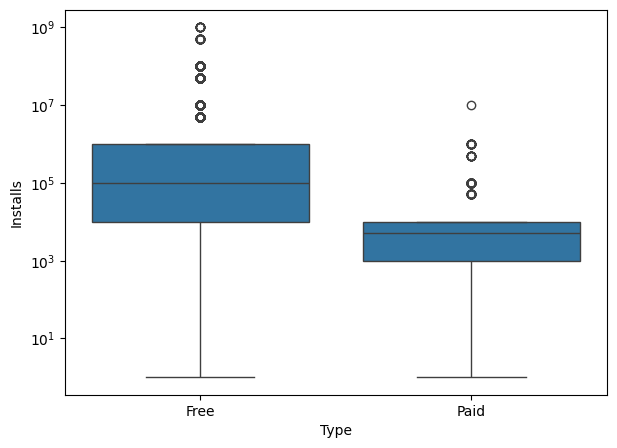

In [3]:
# ============================================================
# GOOGLE PLAY STORE ANALYTICS - CASE STUDY
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/abhik12295/playstore-Dataset/main/googleplaystore.csv"

df = pd.read_csv(url)

# -------------------------------
# Basic Cleaning
# -------------------------------

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = (
    df["Installs"]
      .astype(str)
      .str.replace(",", "")
      .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Size"] = (
    df["Size"]
      .astype(str)
      .str.replace("M", "", regex=False)
      .str.replace("k", "", regex=False)
      .str.replace("Varies with device", "")
)

df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

df = df.dropna()

# ============================================================
# Q1
#
# The Product team wants to quickly explore relationships among:
# Rating, Reviews, Installs and Size.
#
# Which visualization would you choose?
#
# ============================================================

# ANSWER:
# PairPlot

sns.pairplot(
    df[["Rating","Reviews","Installs","Size"]]
)

plt.show()
print()
# ============================================================
# Q2
#
# Compare the relationship between Reviews and Installs
# separately for Free and Paid apps.
#
# Which visualization would you choose?
#
# ============================================================

# ANSWER:
# FacetGrid using relplot()

sns.relplot(
    data=df,
    x="Reviews",
    y="Installs",
    col="Type"
)

plt.show()
print()
# ============================================================
# Q3
#
# Compare Rating distributions for different App Categories.
#
# Which visualization would you choose?
#
# ============================================================

# ANSWER:
# FacetGrid using displot()

top_cat = (
    df["Category"]
      .value_counts()
      .head(6)
      .index
)

sns.displot(
    data=df[df["Category"].isin(top_cat)],
    x="Rating",
    col="Category",
    col_wrap=3
)

plt.show()
print()
# ============================================================
# Q4
#
# Before building a Machine Learning model,
# perform a quick exploratory analysis of
# all numerical variables.
#
# Which visualization would you choose?
#
# ============================================================

# ANSWER:
# PairPlot

sns.pairplot(
    df[["Rating","Reviews","Installs","Size"]]
)

plt.show()
print()
# ============================================================
# Q5
#
# Which App Category has the highest
# average installs?
#
# ============================================================

# ANSWER:
# Horizontal Bar Chart

avg = (
    df.groupby("Category")["Installs"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=avg.values,
    y=avg.index
)

plt.title("Average Installs by Category")

plt.show()
print()
# ============================================================
# Q6
#
# Management wants users to filter
# by:
#
# - Category
# - Type
# - Content Rating
#
# Which visualization/tool would you recommend?
#
# ============================================================

# ANSWER:
#
# Tableau
# Power BI
# Plotly Dash
#
# Reason:
# Interactive filtering and drill-down
# cannot be achieved efficiently using
# static Seaborn plots.

# ============================================================
# Q7
#
# Reviews and Installs appear to have
# a strong relationship.
#
# You now need to present this finding
# to senior management.
#
# Which visualization would you choose?
#
# ============================================================

# ANSWER:
# Scatter Plot
print()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Installs"
)

plt.title("Reviews vs Installs")

plt.show()
print()

# ============================================================
# Q8
#
# Compare Rating distributions
# separately for every App Type
# (Free vs Paid).
#
# Which visualization would you choose?
#
# ============================================================

# ANSWER:
# FacetGrid

sns.displot(
    data=df,
    x="Rating",
    col="Type"
)

plt.show()
print()
# ============================================================
# Q9
#
# Compare Install distributions
# between Free and Paid apps.
#
# Which visualization would you choose
# for executives?
#
# ============================================================

# ANSWER:
# Box Plot

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Type",
    y="Installs"
)

plt.yscale("log")

plt.show()
print()
# ============================================================
# Q10
#
# The CEO wants a dashboard containing:
#
# - Top Categories
# - Rating Distribution
# - Reviews vs Installs
# - Install Distribution
# - Interactive Filters
#
# What would you recommend?
#
# ============================================================

# ANSWER:
#
# Tableau
# Power BI
# Plotly Dash
#
# Reason:
#
# Multiple linked visualizations with
# filters and drill-down capabilities
# are better suited to dashboards than
# a single Seaborn figure.

In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

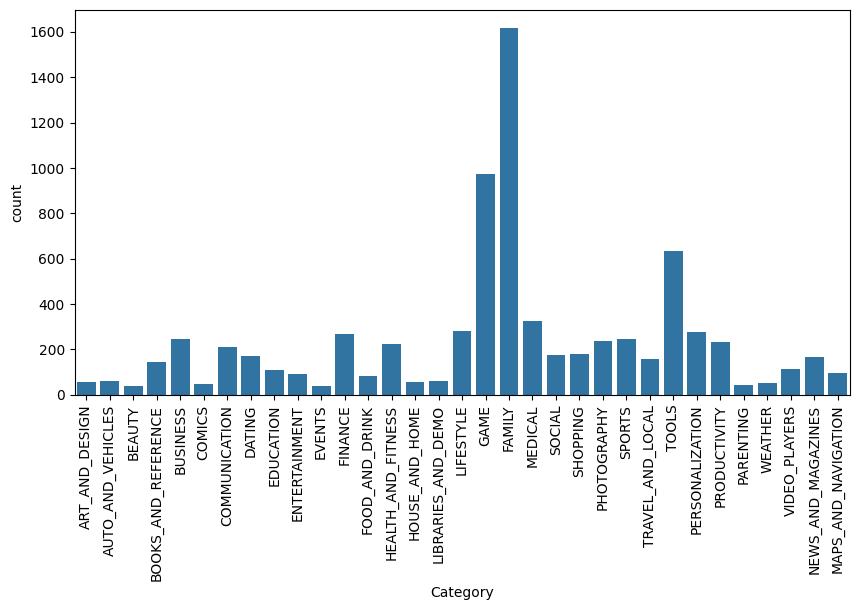


 Insights :
    1.Pepole Love to Watch Family App compare to other category of App
    2.Game and Tools Category is followed by Family Apps



In [5]:
# 📊 Google Play Store Dataset - EDA Case Study Questions

## Q1. Which app category has the highest number of apps?
# **Hint:** Count Plot / Bar Chart
plt.figure(figsize=(10,5))
sns.countplot(x='Category', data=df)
plt.xticks(rotation=90)
plt.show()

print('''
 Insights :
    1.Pepole Love to Watch Family App compare to other category of App
    2.Game and Tools Category is followed by Family Apps
''')

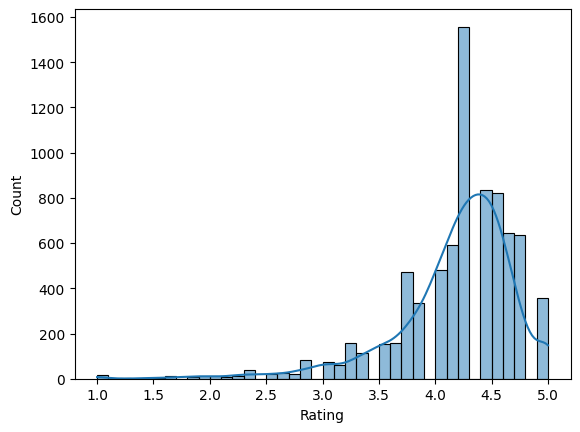


 Insights :
    1.Majeroty of Pepole Give Rating Between 3.5 to 4.5
    2.Some App got Ratting of 5 Out of 5



In [6]:
## Q2. What is the distribution of app ratings?
# **Hint:** Histogram + KDE

sns.histplot(x='Rating', data=df, kde=True,bins = 40)
plt.show()
print('''
 Insights :
    1.Majeroty of Pepole Give Rating Between 3.5 to 4.5
    2.Some App got Ratting of 5 Out of 5
''')

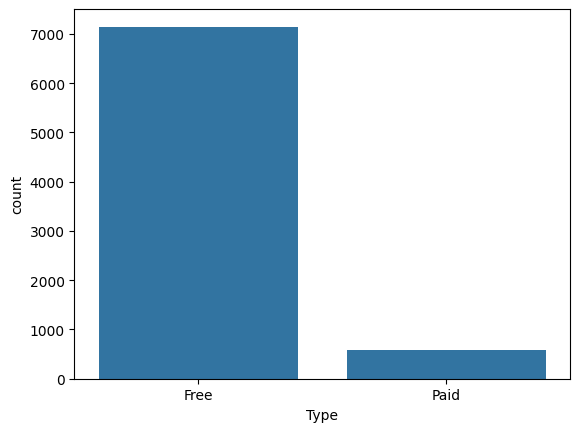


 Insights :
    1.Most Of People Use Free Apps compare to Paid Apps
    2.Aroup 10% of the Pepole Use Paid Apps Compare to Free Apps



In [7]:
## Q3. Compare the number of Free and Paid apps.
# **Hint:** Count Plot / Pie Chart

sns.countplot(x='Type',data = df)
plt.show()
print('''
 Insights :
    1.Most Of People Use Free Apps compare to Paid Apps
    2.Aroup 10% of the Pepole Use Paid Apps Compare to Free Apps
''')

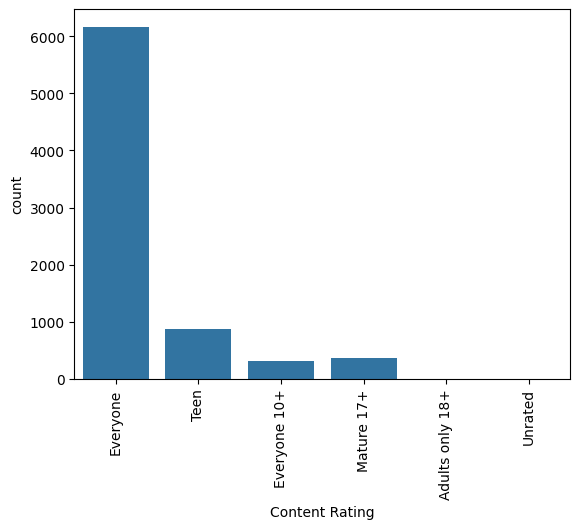


 Insights :
    1.Most Of Pepole Use the Everyone Category App
    2.Then Teen and 10+ Category app used



In [8]:
## Q4. Which Content Rating has the highest number of apps?
# **Hint:** Count Plot
highest_rattings = df.groupby('Rating')['Content Rating'].value_counts()
highest_rattings
sns.countplot(x='Content Rating',data = df)
plt.xticks(rotation=90)
plt.show()
print('''
 Insights :
    1.Most Of Pepole Use the Everyone Category App
    2.Then Teen and 10+ Category app used
''')

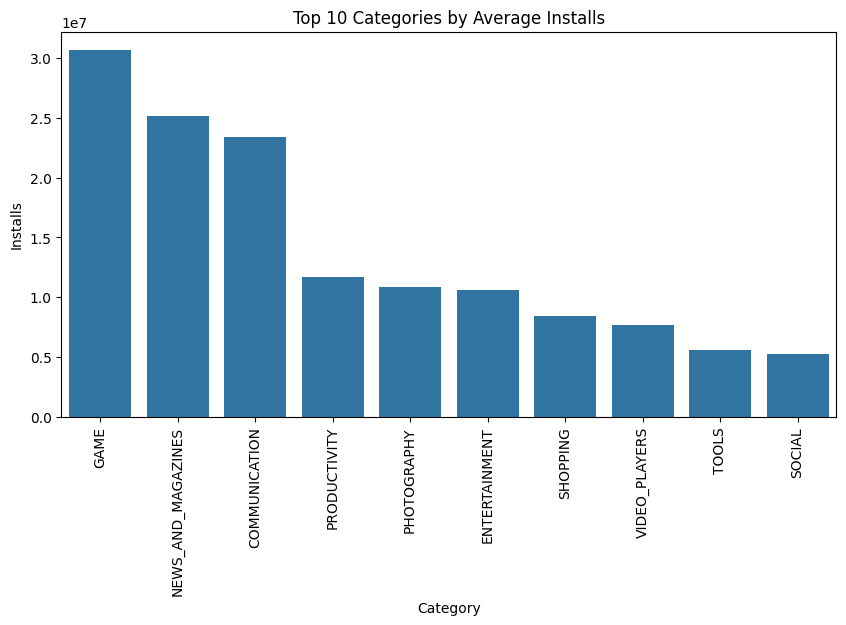

In [11]:
## Q5. Which app categories have the highest average installs?
# **Hint:** Bar Chart
avg = (
    df.groupby('Category')['Installs']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=avg,
    x='Category',
    y='Installs'
)

plt.xticks(rotation=90)
plt.title("Top 10 Categories by Average Installs")
plt.show()

print('''
  Insights :
    1.Gameing App is highest Numbers of Insetalls Compare to other app
    2.Top 3 Most Installs App are Game,News & Magezines , Comunications
''')

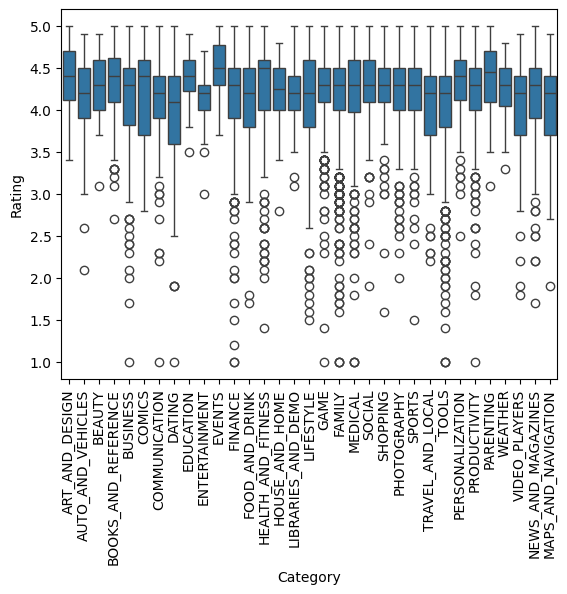

In [10]:
## Q6. Which app categories receive the highest ratings?
# **Hint:** Box Plot
sns.boxplot(x='Category',y='Rating',data=df)
plt.xticks(rotation=90)
plt.show()
print('''
  Insights :
    1.Dating App Has Highest Numbers of Ratings Compare to other app
    2.Then Maps and Food Ordering Apps are highere comapre to other apps
''')

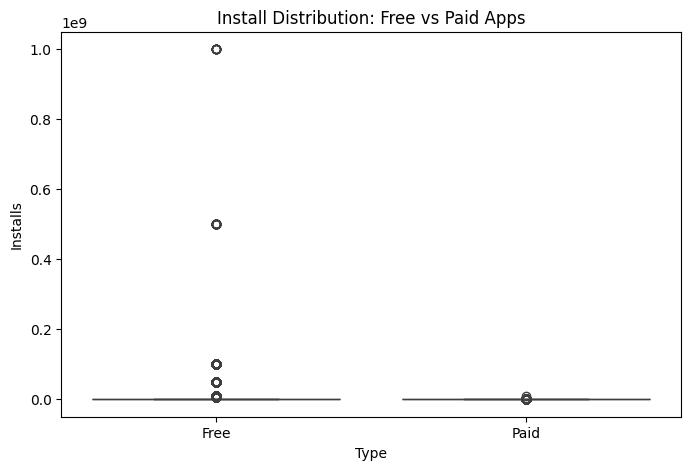


  Insights :
    1.Gameing App is highest Numbers of Insetalls Compare to other app
    2.Top 3 Most Installs App are Game,News & Magezines , Comunications



In [18]:
## Q7. Compare install distributions between Free and Paid apps.
# **Hint:** Box Plot / Violin Plot / Histogram (hue='Type')

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Type',
    y='Installs'
)

plt.title("Install Distribution: Free vs Paid Apps")
plt.show()

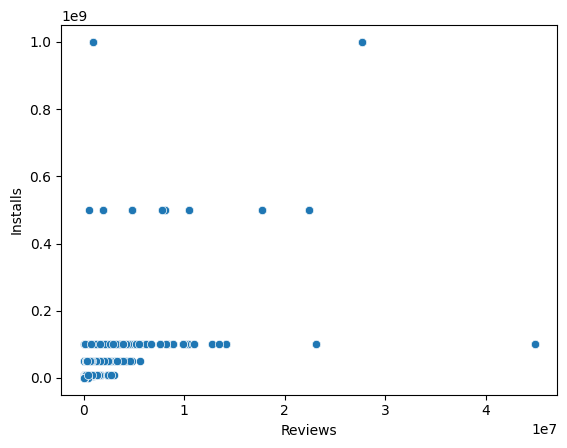

In [19]:
## Q8. Is there a relationship between Reviews and Installs?
# **Hint:** Scatter Plot
sns.scatterplot(x='Reviews',y='Installs',data=df)
plt.show()

print('''
  Insights :
    1.Atleast One Reviews are get good installs
''')

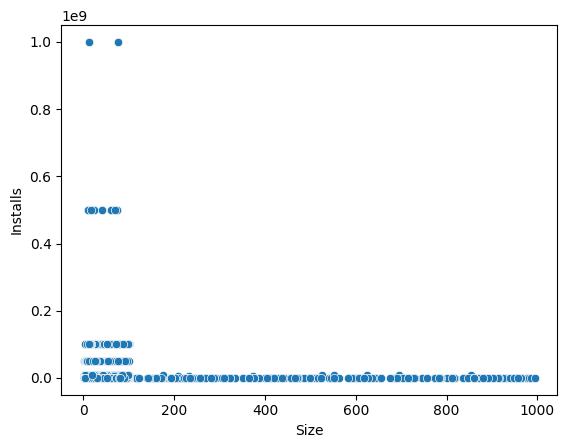


  Insights :
    1.Atleast One App Size is get good installs



In [20]:
## Q9. Does app Size affect Installs?
# **Hint:** Scatter Plot
sns.scatterplot(x='Size',y='Installs',data=df)
plt.show()

print('''
  Insights :
    1.Pepople Mostily install app under 100 mb size
''')

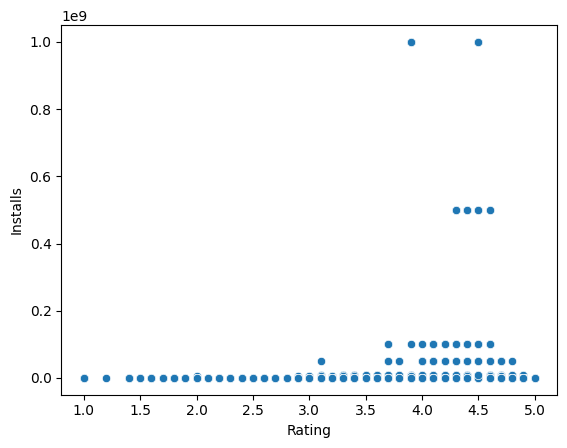


  Insights :
    1.Pepople Mostily install app under 100 mb size



In [21]:
## Q10. Does Rating influence the number of Installs?
# **Hint:** Scatter Plot
sns.scatterplot(x='Rating',y='Installs',data=df)
plt.show()

print('''
  Insights :
    1.Some time Ratings Are Increase the number of installs
''')

# 💼 Business Case Studies

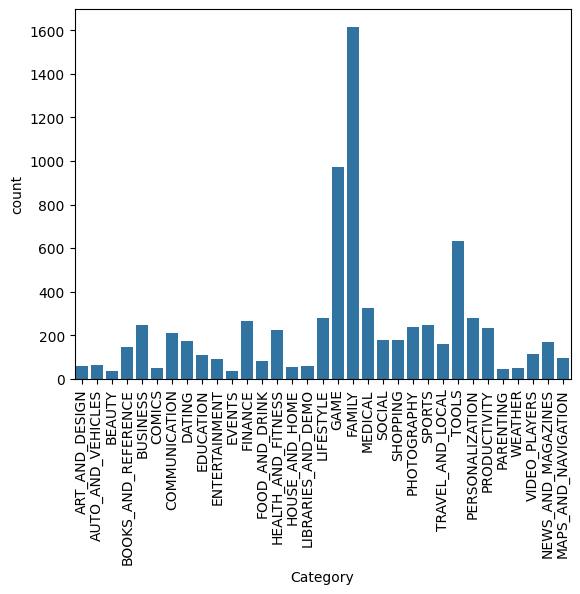


Family type App Has highest number of install but gaming need to higher investment compare to the other category of app


In [24]:

## Case Study 1
# The CEO wants to know which app categories deserve more investment.

# **Hint:** Bar Chart

sns.countplot(x='Category',data = df)
plt.xticks(rotation=90)
plt.show()
print()
print('Family type App Has highest number of install but gaming need to higher investment compare to the other category of app')

In [ ]:
## Case Study 2
# The Marketing team wants to compare user engagement between Free and Paid apps.

# **Hint:** Box Plot / Violin Plot

In [ ]:

## Case Study 3
# The Product team wants to know whether better-rated apps receive more downloads.

# **Hint:** Scatter Plot

In [ ]:
## Case Study 4
# Before building a machine learning model, explore all numerical variables.

# **Hint:** Pair Plot + Correlation Heatmap

In [ ]:
## Case Study 5
# Management wants to identify categories with the happiest users.

# **Hint:** Box Plot

In [ ]:

## Case Study 6
# The Finance team wants to compare app prices across categories.

# **Hint:** Bar Chart / Box Plot


In [ ]:

## Case Study 7
# Which age group has access to the largest number of apps?

# **Hint:** Count Plot

In [ ]:
--

## Case Study 8
# Find the Top 10 app categories based on average installs.

# **Hint:** Horizontal Bar Chart

---

In [ ]:

## Case Study 9
# Identify categories with unusually high or low ratings.

# **Hint:** Box Plot

In [ ]:
---

## Case Study 10
# Management wants an interactive dashboard where users can filter by Category, Type, and Content Rating.

# **Hint:** Streamlit / Power BI / Tableau Dashboard